## SKF:  1-D Free-Fall

### System Dynamics (Section II.A) :contentReference[oaicite:0]{index=0}  
Time step $\Delta t = 1\,$s. State variables are position $z_k$, velocity $v_k$, and gravity $g_k$ (nuisance).  
$$
\begin{aligned}
z_{k+1} &= z_k + v_k\,\Delta t + \tfrac12\,g_k\,\Delta t^2,\\
v_{k+1} &= v_k + g_k\,\Delta t,\\
g_{k+1} &= g_k.
\end{aligned}
$$
Initial values:  
$$
z_0 = 0.8\text{ m},\quad
v_0 = 0.3\text{ m/s},\quad
g_0 = 9.8\text{ m/s}^2,
$$
with variances $\mathrm{Var}(z_0)=\mathrm{Var}(v_0)=\mathrm{Var}(g_0)=1$.  
Measurements of position:  
$$
y_k = z_k + v_k,\quad R = 1.
$$

---

### State-Space Form  
Define  
$$
x_k = \begin{bmatrix}z_k\\[4pt]v_k\end{bmatrix},\quad
F = \begin{bmatrix}1 & \Delta t\\[4pt]0 & 1\end{bmatrix},\quad
B = \begin{bmatrix}\tfrac12\,\Delta t^2\\[6pt]\Delta t\end{bmatrix},\quad
H = \begin{bmatrix}1 & 0\end{bmatrix}.
$$  
Then  
$$
\begin{aligned}
x_{k+1} &= F\,x_k + B\,g_k,\\
y_k     &= H\,x_k + v_k.
\end{aligned}
$$

---

### Consider (Schmidt-Kalman) Filter Equations  
Augment only the covariance with the nuisance parameter $g$:

$$
P = \begin{bmatrix}
P_{xx} & P_{xg}\\[4pt]
P_{gx} & P_{gg}
\end{bmatrix},
\quad
\hat g = g_0 \quad(\text{never updated}).
$$

**Time-Update**  
$$
\begin{aligned}
x_{k+1|k} &= F\,x_{k|k} + B\,\hat g,\\[4pt]
P_{xx,k+1|k} &= F\,P_{xx,k|k}\,F^T
  + F\,P_{xg,k|k}\,B^T
  + B\,P_{gx,k|k}\,F^T
  + B\,P_{gg}\,B^T,\\[4pt]
P_{xg,k+1|k} &= F\,P_{xg,k|k} + B\,P_{gg},\\[4pt]
P_{gg,k+1|k} &= P_{gg,k|k}.
\end{aligned}
$$

**Measurement-Update**  
$$
\begin{aligned}
S_k &= H\,P_{xx,k+1|k}\,H^T + R,\\[4pt]
K_{x,k} &= P_{xx,k+1|k}\,H^T\,S_k^{-1},\\[4pt]
x_{k+1|k+1} &= x_{k+1|k} + K_{x,k}\bigl(y_{k+1} - H\,x_{k+1|k}\bigr),\\[4pt]
P_{xx,k+1|k+1} &= (I - K_{x,k}H)\,P_{xx,k+1|k}\,(I - K_{x,k}H)^T + K_{x,k}\,R\,K_{x,k}^T,\\[4pt]
P_{xg,k+1|k+1} &= (I - K_{x,k}H)\,P_{xg,k+1|k},\\[4pt]
P_{gg,k+1|k+1} &= P_{gg,k+1|k}.
\end{aligned}
$$

---

### Why $g$ Is a “Nuisance” State  
- **Static bias**: $g_{k+1}=g_k$ (no dynamics to update).  
- **Low observability**: position‐only measurements can’t reliably estimate $g$ each step.  
- **Filter consistency**: by “considering” $g$ we propagate its known uncertainty $P_{gg}$ into $P_{xx}$ without risking divergence from poorly observed parameter updates.


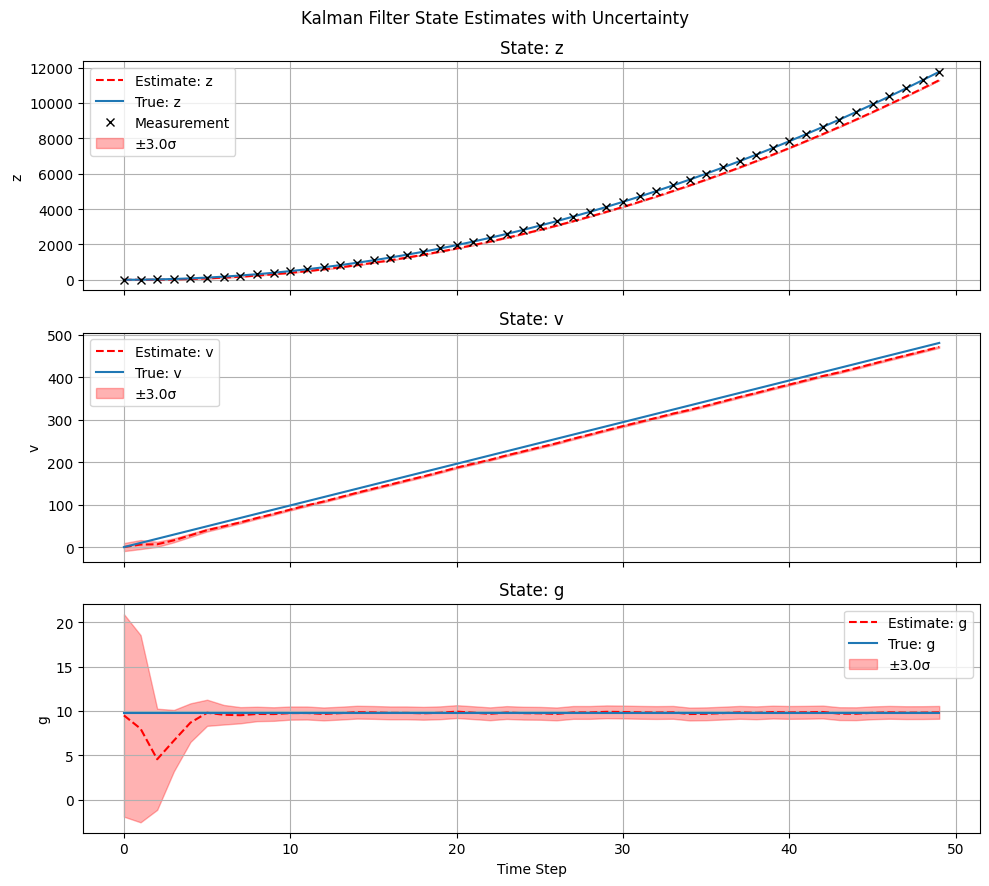

In [ ]:
dt = 1.0

# State‐transition: [z; v; g]
F = np.array([
    [1.0, dt, 0.5*dt**2],
    [0.0, 1.0,        dt],
    [0.0, 0.0,       1.0]
])

# Measurement: position only
H = lambda x,u: np.array([[1.0, 0.0, 0.0]])
h = lambda x,u: np.array([x[0]])

# Noise covariances
Q = np.diag([0.1, 0.1, 0.01])
R = np.array([[1.0]])

# instantiate filters
ekf = pk.EKF(
    f=lambda x,u: F @ x,
    h=h,
    Q=Q, R=R,
    dt=dt,
    system_type=pk.SystemType.DISCRETE_TIME_INVARIANT
)

skf = pk.SKF(
    f=lambda x,u: F @ x,
    h=h,
    Q=Q, R=R,
    dt=dt,
    system_type=pk.SystemType.DISCRETE_TIME_INVARIANT,
    update_mask=np.array([True, True, False])  # freeze g
)

# simulate true motion
N = 50
x_true = np.zeros((N,3))
x_true[0] = [0.0, 0.0, 9.8]
for k in range(1, N):
    x_true[k] = F @ x_true[k-1]

# noisy measurements
y = x_true[:,0] + np.random.randn(N)*np.sqrt(R[0,0])
y_df = pd.DataFrame(y, columns=['z'])

# initial filter guesses (biased g)
g_true = 9.8
g_est = 6
x0 = pd.Series([0.0, 0.0, 9.5], index=['z','v','g'])
P0 = np.diag([10.0, 10.0, 1.0])
P0[2,2] = (g_est - g_true)**2

# run EKF and SKF
x_est_ekf, P_est_ekf = ekf.run(x0, P0, y_df, F, H)
x_est_skf, P_est_skf = skf.run(x0, P0, y_df, F, H)


# align lengths
x_est_ekf = x_est_ekf.iloc[:N]
P_est_ekf = P_est_ekf[:N]
y_df  = y_df.iloc[:N]

ekf.plot_kf_predictions(
    x_est_ekf, P_est_ekf,
    x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),
    y_df=y_df
)



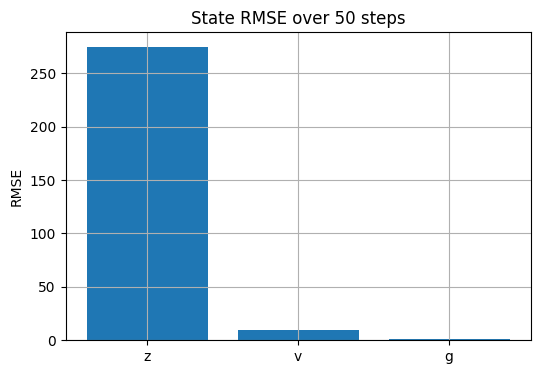

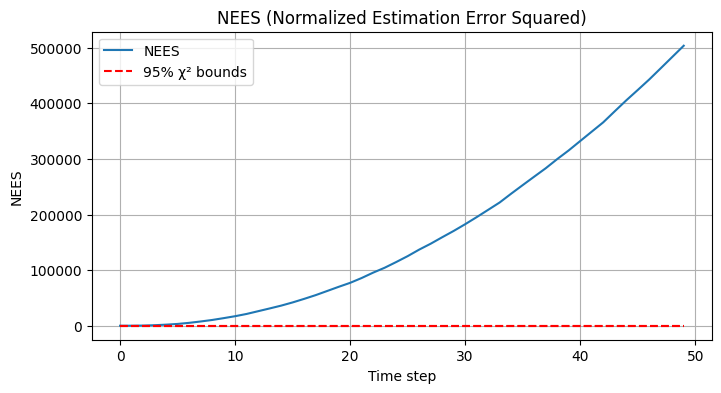

In [ ]:
ekf.plot_error(x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),x_est_df = x_est_ekf,P_est=P_est_ekf)

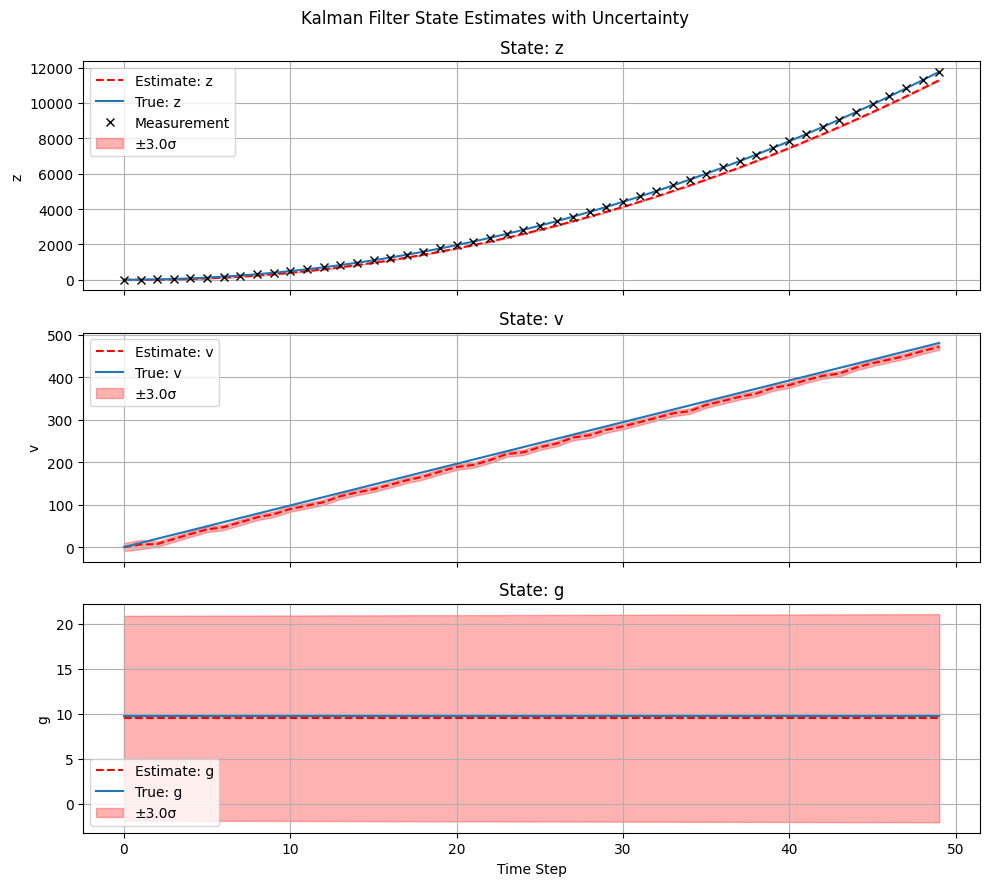

In [ ]:
x_est_skf = x_est_skf.iloc[:N]
P_est_skf = P_est_skf[:N]
skf.plot_kf_predictions(
    x_est_skf, P_est_skf,
    x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),
    y_df=y_df
)

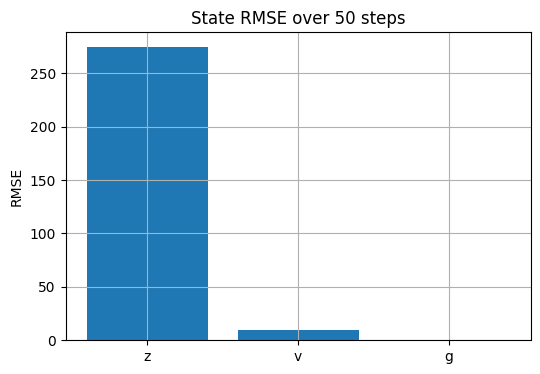

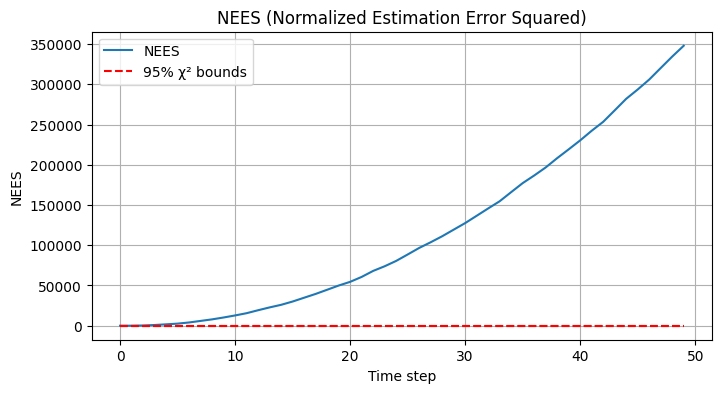

In [ ]:
skf.plot_error(x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),x_est_df = x_est_skf,P_est=P_est_skf)